## gwModelRemP : remnant properties of precessing quasi-circular BBH mergers

`gwModelRemP` augments the aligned-spin baseline `gwModelRemS` with corrections
built from the in-plane spin components, evaluated at the reference separation
$r = 8M$. Inputs are $(q, a_1, a_2, \theta_1, \theta_2, \phi_1, \phi_2)$.

| Quantity | Function |
|---|---|
| Final mass $M_f/M$ | `gwModelRemP_mf` |
| Final spin magnitude $|\chi_f|$ and tilt $\theta_f$ | `gwModelRemP_chif` |
| Peak luminosity $L_{\rm peak}$ | `gwModelRemP_Lpeak` |

The two in-plane spin combinations that drive the corrections are

$$S_\perp = \frac{\sqrt{q^4\chi_{1\perp}^2 + \chi_{2\perp}^2}}{q^2+1},
\qquad
\Delta_\perp = \frac{q\chi_{1\perp} - \chi_{2\perp}}{1+q}.$$

The recoil of a precessing binary is **not** modeled deterministically; see
notebook 6_5 for the probabilistic `gwModelRemP_flow`.

In [1]:
import sys
!{sys.executable} -m pip install -e ../ --no-deps --quiet

import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import gwModels
gwModels.utils.set_rcparams()

lal.MSUN_SI != Msun


### 1. Basic evaluation

In [2]:
q = 2.0
a1, a2 = 0.7, 0.3
theta1, theta2 = np.pi / 3, np.pi / 4
phi1, phi2 = 0.0, 0.0

Mf, af, theta_f, Lpeak = gwModels.remnants.gwModelRemP(
    q, a1, a2, theta1, theta2, phi1, phi2)

print(f'q = {q}, a1 = {a1}, a2 = {a2}')
print(f'theta1 = {np.degrees(theta1):.1f} deg, theta2 = {np.degrees(theta2):.1f} deg')
print()
print(f'  Mf/M           = {Mf:.6f}')
print(f'  |chi_f|        = {af:.6f}')
print(f'  theta_f        = {np.degrees(theta_f):.3f} deg')
print(f'  L_peak [c^5/G] = {Lpeak:.6e}')

q = 2.0, a1 = 0.7, a2 = 0.3
theta1 = 60.0 deg, theta2 = 45.0 deg

  Mf/M           = 0.950970
  |chi_f|        = 0.767568
  theta_f        = 16.596 deg
  L_peak [c^5/G] = 9.767346e-04


In [3]:
# The derived in-plane spin variables are exposed directly
chi1z, chi2z, S_perp, Delta_perp = gwModels.remnants.spin_projections(
    np.array(q), np.array(a1), np.array(a2), np.array(theta1), np.array(theta2))

print(f'  chi1z      = {float(chi1z):+.6f}')
print(f'  chi2z      = {float(chi2z):+.6f}')
print(f'  S_perp     = {float(S_perp):.6f}')
print(f'  Delta_perp = {float(Delta_perp):+.6f}')

  chi1z      = +0.350000
  chi2z      = +0.212132
  S_perp     = 0.486826
  Delta_perp = +0.333435


### 2. Dependence on the spin tilt\n\nAll corrections scale as $S_\perp^2$, so they vanish for aligned ($\theta = 0$) and anti-aligned ($\theta = \pi$) spins and peak when the spins lie in the orbital plane.

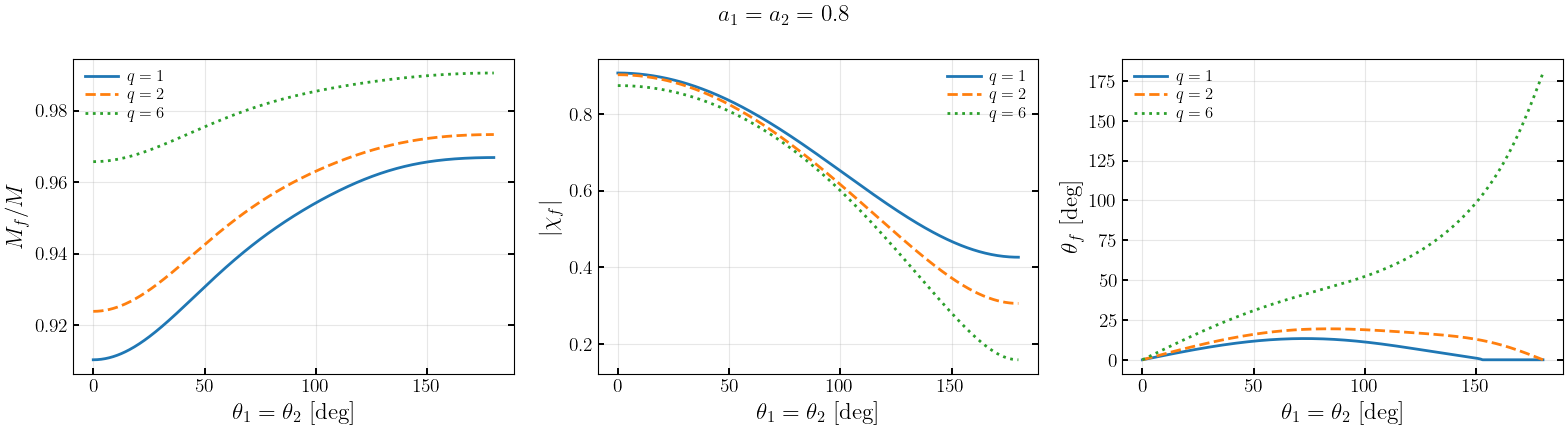

In [4]:
theta_arr = np.linspace(0, np.pi, 400)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for q_fix, ls in [(1.0, '-'), (2.0, '--'), (6.0, ':')]:
    Mf, af, thf, Lp = gwModels.remnants.gwModelRemP(
        q_fix, 0.8, 0.8, theta_arr, theta_arr, 0.0, 0.0)
    axes[0].plot(np.degrees(theta_arr), Mf, ls, lw=2, label=rf'$q={q_fix:.0f}$')
    axes[1].plot(np.degrees(theta_arr), af, ls, lw=2, label=rf'$q={q_fix:.0f}$')
    axes[2].plot(np.degrees(theta_arr), np.degrees(thf), ls, lw=2, label=rf'$q={q_fix:.0f}$')

for ax, lab in zip(axes, ['$M_f/M$', r'$|\chi_f|$', r'$\theta_f$ [deg]']):
    ax.set_xlabel(r'$\theta_1 = \theta_2$ [deg]')
    ax.set_ylabel(lab)
    ax.legend(frameon=False)
    ax.grid(alpha=0.3)

plt.suptitle(r'$a_1 = a_2 = 0.8$')
plt.tight_layout()
plt.show()

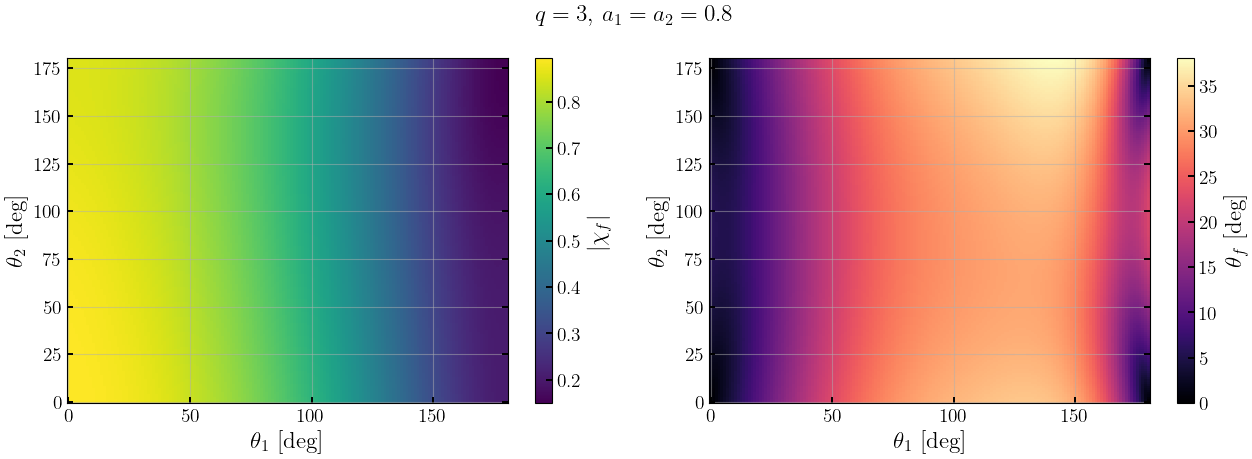

In [5]:
# Two-dimensional view: remnant spin magnitude over (theta1, theta2)
th1 = np.linspace(0, np.pi, 160)
th2 = np.linspace(0, np.pi, 160)
T1, T2 = np.meshgrid(th1, th2)

_, AF, THF, _ = gwModels.remnants.gwModelRemP(3.0, 0.8, 0.8, T1, T2, 0.0, 0.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
im0 = axes[0].pcolormesh(np.degrees(T1), np.degrees(T2), AF, shading='auto', cmap='viridis')
cb0 = fig.colorbar(im0, ax=axes[0])
cb0.set_label(r'$|\chi_f|$')

im1 = axes[1].pcolormesh(np.degrees(T1), np.degrees(T2), np.degrees(THF),
                         shading='auto', cmap='magma')
cb1 = fig.colorbar(im1, ax=axes[1])
cb1.set_label(r'$\theta_f$ [deg]')

for ax in axes:
    ax.set_xlabel(r'$\theta_1$ [deg]')
    ax.set_ylabel(r'$\theta_2$ [deg]')

plt.suptitle(r'$q=3$, $a_1=a_2=0.8$')
plt.tight_layout()
plt.show()

### 3. The non-precessing limit is exact\n\nEvery augmentation term carries a factor of $S_\perp^2$ or $\Delta_\perp^2$, so at zero in-plane spin `gwModelRemP` reduces to `gwModelRemS` bit-for-bit, not merely to within round-off.

In [6]:
q_t, chi1z_t, chi2z_t = 3.0, 0.5, -0.3

# Aligned primary (theta1=0) and anti-aligned secondary (theta2=pi)
Mf_p, af_p, thf_p, Lp_p = gwModels.remnants.gwModelRemP(
    q_t, 0.5, 0.3, 0.0, np.pi, 0.0, 0.0)
Mf_s, chif_s, Lp_s, _, _ = gwModels.remnants.gwModelRemS(q_t, chi1z_t, chi2z_t)

print(f'  gwModelRemS : Mf = {Mf_s:.15f}   |chi_f| = {abs(chif_s):.15f}')
print(f'  gwModelRemP : Mf = {Mf_p:.15f}   |chi_f| = {af_p:.15f}')
print()
print(f'  exact match : Mf {Mf_p == Mf_s},  spin {af_p == abs(chif_s)},  Lpeak {Lp_p == Lp_s}')
print(f'  theta_f     = {np.degrees(thf_p):.3e} deg')

  gwModelRemS : Mf = 0.961686984172706   |chi_f| = 0.746635394858050
  gwModelRemP : Mf = 0.961686984172706   |chi_f| = 0.746635394858050

  exact match : Mf True,  spin True,  Lpeak True
  theta_f     = 0.000e+00 deg


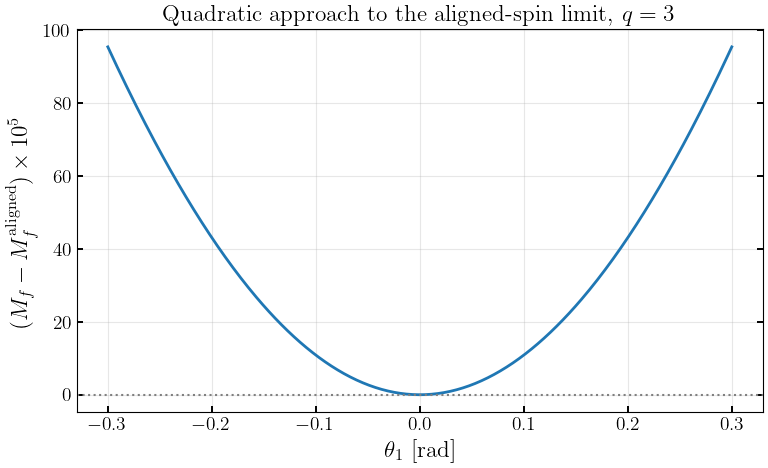

In [7]:
# Continuity: sweep a small tilt through zero
eps = np.linspace(-0.3, 0.3, 400)
Mf_c = np.array([gwModels.remnants.gwModelRemP(3.0, 0.6, 0.4, abs(t), 0.0, 0.0, 0.0)[0]
                 for t in eps])
Mf_ref = gwModels.remnants.gwModelRemS_mf(3.0, 0.6, 0.4)

plt.figure(figsize=(8, 5))
plt.plot(eps, (Mf_c - Mf_ref) * 1e5, lw=2)
plt.axhline(0, color='grey', ls=':', lw=1.5)
plt.xlabel(r'$\theta_1$ [rad]')
plt.ylabel(r'$(M_f - M_f^{\rm aligned}) \times 10^{5}$')
plt.title(r'Quadratic approach to the aligned-spin limit, $q=3$')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4. Comparison with other precessing remnant models

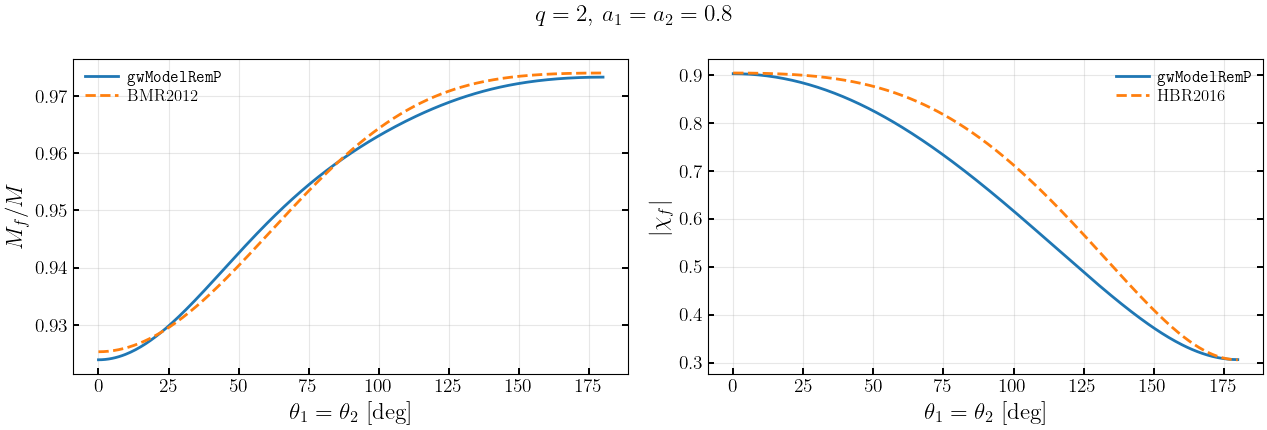

In [8]:
# HBR/BMR give the precessing final mass and spin magnitude
theta_c = np.linspace(0, np.pi, 300)
q_c, a1_c, a2_c = 2.0, 0.8, 0.8

Mf_P, af_P, _, _ = gwModels.remnants.gwModelRemP(
    q_c, a1_c, a2_c, theta_c, theta_c, 0.0, 0.0)

Mf_B = np.array([gwModels.remnants.bbh_final_mass_precessing_BMR2012(
    q_c, a1_c, a2_c, t, t, 0.0) for t in theta_c])
af_H = np.array([gwModels.remnants.bbh_final_spin_precessing_HBR2016(
    q_c, a1_c, a2_c, t, t, 0.0) for t in theta_c])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(np.degrees(theta_c), Mf_P, lw=2, label=r'\texttt{gwModelRemP}')
axes[0].plot(np.degrees(theta_c), Mf_B, '--', lw=2, label='BMR2012')
axes[0].set_ylabel('$M_f/M$')

axes[1].plot(np.degrees(theta_c), af_P, lw=2, label=r'\texttt{gwModelRemP}')
axes[1].plot(np.degrees(theta_c), af_H, '--', lw=2, label='HBR2016')
axes[1].set_ylabel(r'$|\chi_f|$')

for ax in axes:
    ax.set_xlabel(r'$\theta_1 = \theta_2$ [deg]')
    ax.legend(frameon=False)
    ax.grid(alpha=0.3)

plt.suptitle(rf'$q={q_c:.0f}$, $a_1=a_2={a1_c}$')
plt.tight_layout()
plt.show()

### 5. Timing

In [9]:
sizes = [1, 10, 100, 1000, 10000, 100000]
means = []

for n in sizes:
    q_t = np.random.uniform(1, 10, n)
    a1_t = np.random.uniform(0, 1, n)
    a2_t = np.random.uniform(0, 1, n)
    t1_t = np.random.uniform(0, np.pi, n)
    t2_t = np.random.uniform(0, np.pi, n)
    reps = 20 if n <= 10000 else 5
    t = []
    for _ in range(reps):
        t0 = time.perf_counter()
        gwModels.remnants.gwModelRemP(q_t, a1_t, a2_t, t1_t, t2_t, 0.0, 0.0)
        t.append(time.perf_counter() - t0)
    means.append(np.mean(t))

means = np.array(means)
print(f'{'N':>8s}  {'time':>10s}  {'per binary':>13s}')
for n, m in zip(sizes, means):
    print(f'{n:>8d}  {m*1e3:8.3f} ms  {m/n*1e6:10.4f} us')

       N        time     per binary
       1     0.184 ms    184.1896 us
      10     0.183 ms     18.3104 us
     100     0.207 ms      2.0733 us
    1000     0.415 ms      0.4155 us
   10000     2.700 ms      0.2700 us
  100000    28.459 ms      0.2846 us


In [10]:
# gwModelRemP against its own aligned-spin baseline: the precessing
# augmentation costs little beyond the gwModelRemS evaluation it wraps
n = 20000
q_t = np.random.uniform(1, 10, n)
a1_t = np.random.uniform(0, 1, n)
a2_t = np.random.uniform(0, 1, n)
t1_t = np.random.uniform(0, np.pi, n)
t2_t = np.random.uniform(0, np.pi, n)
c1_t = a1_t * np.cos(t1_t)
c2_t = a2_t * np.cos(t2_t)

timings = {}
for name, fn in [
    ('gwModelRemS (3 quantities)',
     lambda: [gwModels.remnants.gwModelRemS_mf(q_t, c1_t, c2_t),
              gwModels.remnants.gwModelRemS_chif(q_t, c1_t, c2_t),
              gwModels.remnants.gwModelRemS_Lpeak(q_t, c1_t, c2_t)]),
    ('gwModelRemP (4 quantities)',
     lambda: gwModels.remnants.gwModelRemP(q_t, a1_t, a2_t, t1_t, t2_t, 0.0, 0.0)),
]:
    t = []
    for _ in range(20):
        t0 = time.perf_counter()
        fn()
        t.append(time.perf_counter() - t0)
    timings[name] = np.mean(t)
    print(f'  {name:>28s} : {np.mean(t)*1e3:7.3f} ms for {n} binaries')

print()
print(f'  precessing overhead : {timings["gwModelRemP (4 quantities)"]/timings["gwModelRemS (3 quantities)"]:.2f}x')

    gwModelRemS (3 quantities) :   4.048 ms for 20000 binaries
    gwModelRemP (4 quantities) :   5.366 ms for 20000 binaries

  precessing overhead : 1.33x


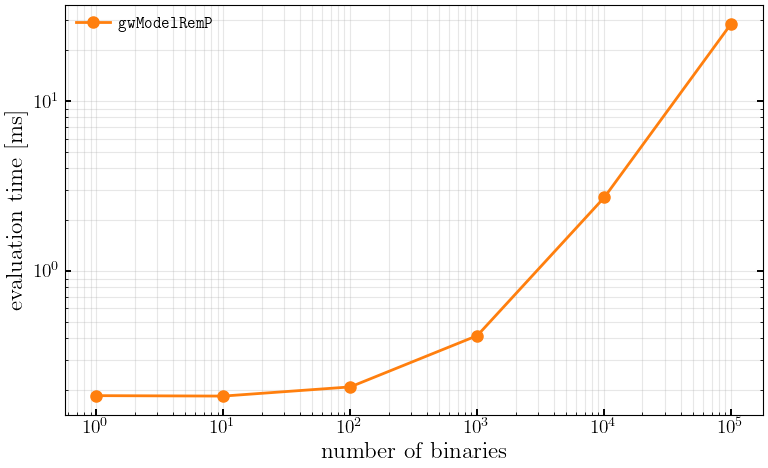

In [11]:
plt.figure(figsize=(8, 5))
plt.loglog(sizes, means * 1e3, 'o-', lw=2, ms=8, color='C1',
           label=r'\texttt{gwModelRemP}')
plt.xlabel('number of binaries')
plt.ylabel('evaluation time [ms]')
plt.legend(frameon=False)
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()